In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kprototypes import KPrototypes
import pickle
import os

sns.set_theme(style="whitegrid")

In [2]:
# Memuat data raw yang sudah di-split
X_train = pd.read_csv('../dataset/processed/X_train_raw.csv')
X_test = pd.read_csv('../dataset/processed/X_test_raw.csv')

# Mengidentifikasi kolom kategorikal dan indeks posisinya
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
cat_idx = [X_train.columns.get_loc(col) for col in cat_cols]

# K-Prototypes mewajibkan konversi eksplisit ke tipe string untuk kolom kategorikal
X_train[cat_cols] = X_train[cat_cols].astype(str)
X_test[cat_cols] = X_test[cat_cols].astype(str)

print(f"Total Kolom Kategorikal: {len(cat_cols)}")

Total Kolom Kategorikal: 17


C:\Users\abdul khahar\AppData\Local\Temp\ipykernel_2596\3389686532.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


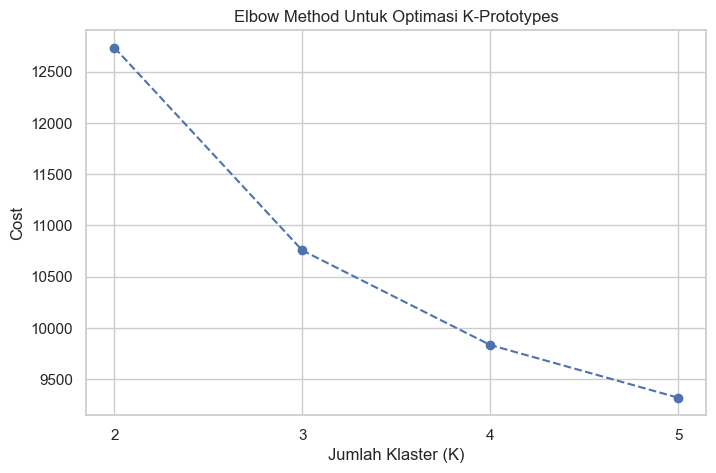

In [3]:
# Evaluasi Jumlah Klaster Optimal (Elbow Method)

costs = []
K_range = range(2, 6) # Menguji k=2 hingga k=5

# Mengubah dataframe ke array numpy untuk K-Prototypes
X_train_matrix = X_train.values

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_jobs=-1)
    kproto.fit(X_train_matrix, categorical=cat_idx)
    costs.append(kproto.cost_)

# Plot visualisasi Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, costs, marker='o', linestyle='--', color='b')
plt.title('Elbow Method Untuk Optimasi K-Prototypes')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Cost')
plt.xticks(K_range)
plt.show()

In [4]:
# Pelatihan Model Final & Ekspor (ambil K optimal secara domain)

OPTIMAL_K = 3 

# Final K-Prototypes Model
final_kproto = KPrototypes(n_clusters=OPTIMAL_K, init='Cao', random_state=42, n_jobs=-1)
final_kproto.fit(X_train_matrix, categorical=cat_idx)

# Prediksi label klaster pada X_train dan X_test
train_clusters = final_kproto.predict(X_train_matrix, categorical=cat_idx)
test_clusters = final_kproto.predict(X_test.values, categorical=cat_idx)

# Menambahkan label klaster sebagai fitur prediktor baru ke DataFrame
X_train['lifestyle_cluster'] = train_clusters
X_test['lifestyle_cluster'] = test_clusters

# Menampilkan karakteristik pusat klaster (Centroids)
print("Karakteristik Numerik Pusat Klaster:")
print(final_kproto.cluster_centroids_[:, :X_train.select_dtypes(exclude=['object']).shape[1]])

# --- EKSPOR DATA DAN MODEL ---
# Ekspor data yang sudah memiliki fitur cluster
X_train.to_csv('../dataset/processed/X_train_clustered.csv', index=False)
X_test.to_csv('../dataset/processed/X_test_clustered.csv', index=False)

# Memastikan folder model tersedia
os.makedirs('../model', exist_ok=True)

# Mengekspor objek model K-Prototypes menggunakan Pickle untuk Streamlit
with open('../model/kprototypes_model.pkl', 'wb') as f:
    pickle.dump(final_kproto, f)

print("\n[INFO] K-Prototypes berhasil dilatih. Data berfitur klaster dan model .pkl telah diekspor.")

Karakteristik Numerik Pusat Klaster:
[['16.628865979381445' '2.5017182130584192' '2.2714776632302405'
  '1.5807560137457044' '1.9725085910652922' '0.20618556701030927'
  '3.993127147766323' '3.1993127147766325' '3.106529209621993'
  '1.3711340206185567' '2.1305841924398625' '3.6151202749140894'
  '0.6529209621993127' 'GP']
 ['16.717277486910994' '2.6178010471204187' '2.3612565445026177'
  '1.5863874345549738' '1.87434554973822' '0.24607329842931938'
  '3.8010471204188483' '3.167539267015707' '3.235602094240838'
  '1.5183246073298429' '2.3821989528795813' '3.4345549738219896'
  '6.12565445026178' 'GP']
 ['17.37837837837838' '2.3783783783783785' '2.5405405405405403'
  '1.5135135135135136' '1.5945945945945945' '0.5135135135135135'
  '3.7567567567567566' '2.972972972972973' '3.3513513513513513'
  '2.2972972972972974' '2.8378378378378377' '3.5945945945945947'
  '16.08108108108108' 'GP']]

[INFO] K-Prototypes berhasil dilatih. Data berfitur klaster dan model .pkl telah diekspor.


=== PROFIL KATEGORIKAL (NILAI MAYORITAS PER KLASTER) ===


C:\Users\abdul khahar\AppData\Local\Temp\ipykernel_2596\3559685833.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clustered.select_dtypes(include=['object']).columns.tolist()


,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
lifestyle_cluster,,,,,,,,,,,,,,,,,
0,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no
1,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no
2,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no



=== PROFIL NUMERIK (RATA-RATA PER KLASTER) ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences
lifestyle_cluster,,,,,,,,,,,,,
0,16.63,2.50,2.27,1.58,1.97,0.21,3.99,3.20,3.11,1.37,2.13,3.62,0.65
1,16.72,2.62,2.36,1.59,1.87,0.25,3.80,3.17,3.24,1.52,2.38,3.43,6.13
2,17.38,2.38,2.54,1.51,1.59,0.51,3.76,2.97,3.35,2.30,2.84,3.59,16.08


C:\Users\abdul khahar\AppData\Local\Temp\ipykernel_2596\3559685833.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], x='lifestyle_cluster', y='absences', data=df_clustered, palette='Set2')
C:\Users\abdul khahar\AppData\Local\Temp\ipykernel_2596\3559685833.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], x='lifestyle_cluster', y='Walc', data=df_clustered, palette='Set2')
C:\Users\abdul khahar\AppData\Local\Temp\ipykernel_2596\3559685833.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 0], x=

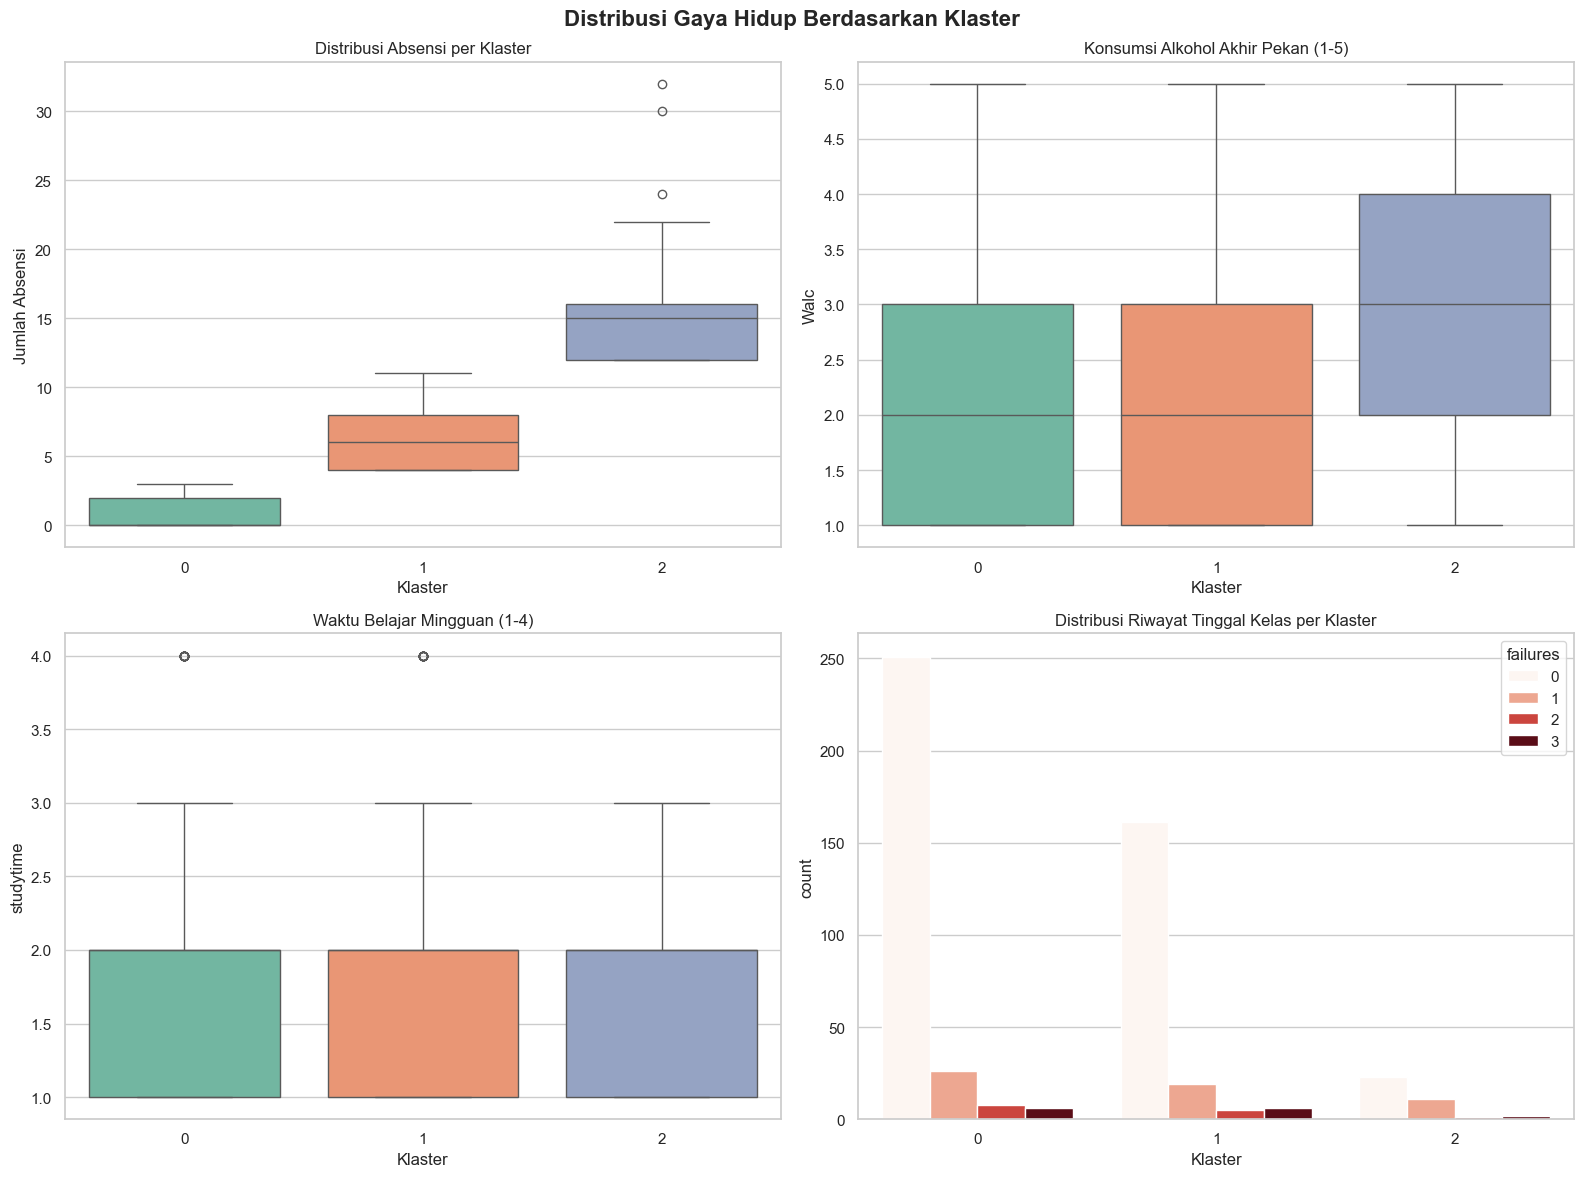

In [5]:
# Visualisasi dan Analisis Profil Klaster
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan data yang digunakan adalah data yang sudah memiliki kolom 'lifestyle_cluster'
df_clustered = pd.read_csv('../dataset/processed/X_train_clustered.csv')

# 1. ANALISIS KATEGORIKAL (Modus dari masing-masing klaster)
cat_cols = df_clustered.select_dtypes(include=['object']).columns.tolist()
if 'lifestyle_cluster' in cat_cols:
    cat_cols.remove('lifestyle_cluster')

print("=== PROFIL KATEGORIKAL (NILAI MAYORITAS PER KLASTER) ===")
cluster_modes = df_clustered.groupby('lifestyle_cluster')[cat_cols].agg(lambda x: x.mode()[0])
display(cluster_modes)

# 2. ANALISIS NUMERIK (Rata-rata dari masing-masing klaster)
num_cols = df_clustered.select_dtypes(exclude=['object']).columns.tolist()
if 'lifestyle_cluster' in num_cols:
    num_cols.remove('lifestyle_cluster')

print("\n=== PROFIL NUMERIK (RATA-RATA PER KLASTER) ===")
cluster_means = df_clustered.groupby('lifestyle_cluster')[num_cols].mean().round(2)
display(cluster_means)

# 3. VISUALISASI DISTRIBUSI FITUR KUNCI
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribusi Gaya Hidup Berdasarkan Klaster', fontsize=16, fontweight='bold')

# Grafik A: Absensi
sns.boxplot(ax=axes[0, 0], x='lifestyle_cluster', y='absences', data=df_clustered, palette='Set2')
axes[0, 0].set_title('Distribusi Absensi per Klaster')
axes[0, 0].set_xlabel('Klaster')
axes[0, 0].set_ylabel('Jumlah Absensi')

# Grafik B: Konsumsi Alkohol Akhir Pekan
sns.boxplot(ax=axes[0, 1], x='lifestyle_cluster', y='Walc', data=df_clustered, palette='Set2')
axes[0, 1].set_title('Konsumsi Alkohol Akhir Pekan (1-5)')
axes[0, 1].set_xlabel('Klaster')

# Grafik C: Waktu Belajar
sns.boxplot(ax=axes[1, 0], x='lifestyle_cluster', y='studytime', data=df_clustered, palette='Set2')
axes[1, 0].set_title('Waktu Belajar Mingguan (1-4)')
axes[1, 0].set_xlabel('Klaster')

# Grafik D: Riwayat Gagal
sns.countplot(ax=axes[1, 1], x='lifestyle_cluster', hue='failures', data=df_clustered, palette='Reds')
axes[1, 1].set_title('Distribusi Riwayat Tinggal Kelas per Klaster')
axes[1, 1].set_xlabel('Klaster')

plt.tight_layout()
plt.show()

1. Klaster 0: Profil Disiplin & Aman (Low Risk)
Karakteristik Visual: Kotak hijau pada grafik absensi sangat gepeng dan berada di angka bawah (0 hingga 3). Mereka nyaris tidak pernah bolos sekolah. Konsumsi alkohol mereka juga cenderung rendah (median 2), dan batang riwayat kegagalan (failures = 0) sangat mendominasi.

Makna: Ini adalah kelompok siswa teladan atau sangat disiplin. Mereka menjaga kehadiran dengan ketat dan menghindari kebiasaan berisiko di akhir pekan.

Teks untuk Aplikasi: "Disiplin tinggi, tingkat absensi sangat rendah (mendekati nol), dan konsumsi alkohol terkendali. Profil siswa dengan fondasi akademik yang aman."

2. Klaster 1: Profil Moderat & Sosial (Medium Risk)
Karakteristik Visual: Kotak oranye menunjukkan absensi berada di tingkat menengah (berkisar antara 4 hingga 11 kali). Waktu belajar (studytime) dan tingkat konsumsi alkohol mereka sangat identik dengan Klaster 0.

Makna: Ini adalah gambaran siswa pada umumnya (rata-rata). Mereka mungkin sesekali membolos atau memiliki aktivitas lain di luar sekolah, tetapi masih dalam batas wajar dan tidak merusak ritme belajar mereka secara fatal.

Teks untuk Aplikasi: "Profil moderat. Tingkat absensi menengah, gaya hidup sosial standar, serta waktu belajar dan performa akademik yang cukup stabil."

3. Klaster 2: Profil Berisiko & Indisipliner (High Risk)
Karakteristik Visual: Ini yang paling mencolok. Kotak ungu pada grafik absensi melesat sangat tinggi (kuartil bawah saja dimulai dari angka 12, dengan outlier mencapai 30+). Selain itu, konsumsi alkohol akhir pekan (Walc) mereka adalah yang tertinggi (median 3, menjangkau angka 5).

Makna: Kelompok ini sangat bermasalah secara perilaku. Tingginya angka bolos yang dikombinasikan dengan gaya hidup bebas di akhir pekan menjadi red flag (peringatan keras) bagi Guru BK. Menariknya, jumlah siswa di klaster ini jauh lebih sedikit dibandingkan klaster lain (terlihat dari total count di grafik riwayat gagal), mengonfirmasi bahwa data kita memang imbalanced.

Teks untuk Aplikasi: "Risiko tinggi. Ditandai dengan tingkat absensi ekstrem (>12 kali), tingginya konsumsi alkohol di akhir pekan, dan indikasi masalah kedisiplinan kronis."